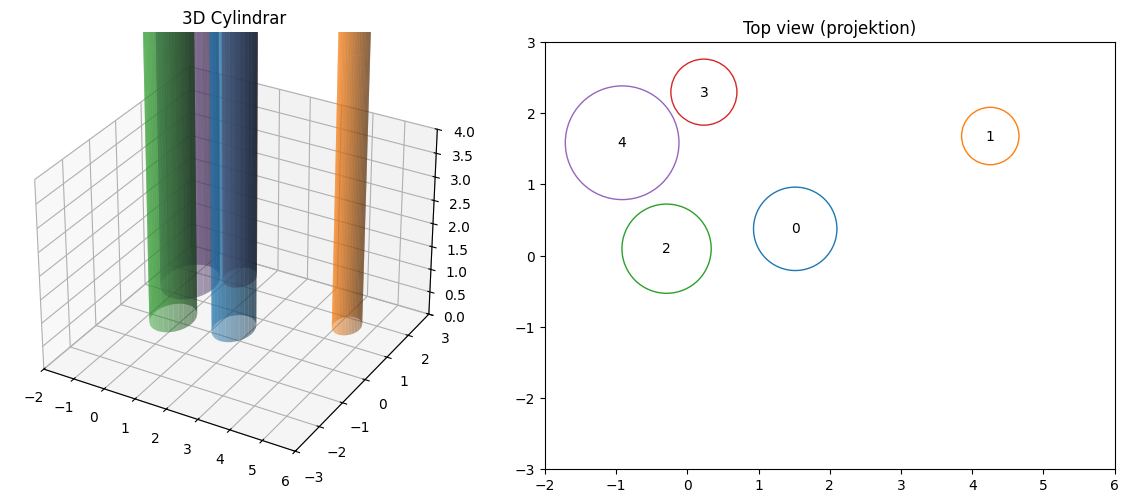

In [1]:
from cylinder_generator import generate_cylinders
from camera_model import compute_camera_pair
from plotting import draw_camera
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Generera data
# -----------------------
cylinders, bounds= generate_cylinders(seed=10)
(xmin, xmax, ymin, ymax) = bounds

# färger
cmap = plt.get_cmap("tab10")
colors = {i: plt.cm.tab10(i % 10) for i in range(100)}

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(12, 5))

# --- 3D plot ---
ax3d = fig.add_subplot(1, 2, 1, projection='3d')

theta = np.linspace(0, 2*np.pi, 30)

for i, (x, y, r, h) in enumerate(cylinders):
    z = np.linspace(0, h, 10)
    theta_grid, z_grid = np.meshgrid(theta, z)

    X = x + r * np.cos(theta_grid)
    Y = y + r * np.sin(theta_grid)
    Z = z_grid

    ax3d.plot_surface(X, Y, Z, color=colors[i], alpha=0.5)

    # centrum
    ax3d.text(x, y, h, str(i))

ax3d.set_title("3D Cylindrar")
ax3d.set_xlim(xmin, xmax)
ax3d.set_ylim(ymin, ymax)
ax3d.set_zlim(0, 4)

# --- Top view (2D) ---
ax2d = fig.add_subplot(1, 2, 2)

for i, (x, y, r, h) in enumerate(cylinders):
    circ = plt.Circle((x, y), r, fill=False, color=colors[i])
    ax2d.add_patch(circ)
    ax2d.text(x, y, str(i), ha='center', va='center')

ax2d.set_aspect('equal')
ax2d.set_xlim(xmin, xmax)
ax2d.set_ylim(ymin, ymax)
ax2d.set_title("Top view (projektion)")

plt.tight_layout()
plt.show()

cyl 0: u_range = [-0.39, -0.20]
cyl 1: u_range = [-0.74, -0.48]
cyl 2: u_range = [-0.36, -0.21]
cyl 3: u_range = [-0.69, -0.55]
cyl 4: u_range = [-0.59, -0.39]
cyl 0: v_range = [-4.04, 4.04]
cyl 1: v_range = [-7.93, 7.93]
cyl 2: v_range = [-3.14, 3.14]
cyl 3: v_range = [-3.78, 3.78]
cyl 4: v_range = [-3.15, 3.15]
Camera 1 ser cylindrar: [0, 1, 2, 3, 4]
Camera 2 ser cylindrar: [0, 1, 2, 4]
FOV: -0.5 0.5
FOV: -0.5 0.5


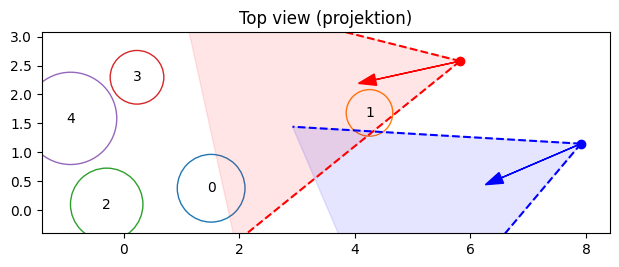

In [2]:
from camera_model import compute_camera_pair
from plotting import draw_fov_cone

# -----------------------
# Skapa kamerapar + projektion
# -----------------------
cam1, cam2, proj1, proj2 = compute_camera_pair(cylinders, bounds, seed=20)

for (i, u_min, u_max, v_min, v_max, d) in proj2:
    print(f"cyl {i}: u_range = [{u_min:.2f}, {u_max:.2f}]")

for (i, u_min, u_max, v_min, v_max, d) in proj2:
    print(f"cyl {i}: v_range = [{v_min:.2f}, {v_max:.2f}]")

# -----------------------
# Synliga cylindrar (FOV-test)
# -----------------------
fov_u = 0.5
fov_v = 1.0

def visible_cylinders(projections):
    visible = []

    for (i, u_min, u_max, v_min, v_max, d) in projections:

        # horisontell FOV
        if u_max < -fov_u or u_min > fov_u:
            continue

        # vertikal FOV
        if v_max < -fov_v or v_min > fov_v:
            continue

        visible.append(i)

    return visible


vis1 = visible_cylinders(proj1)
vis2 = visible_cylinders(proj2)

print("Camera 1 ser cylindrar:", vis1)
print("Camera 2 ser cylindrar:", vis2)

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(12, 5))

# --- Top view (2D) ---
# inkludera kameror i bounds
all_x = [x for (x, _, _, _) in cylinders] + [cam1.c[0], cam2.c[0]]
all_y = [y for (_, y, _, _) in cylinders] + [cam1.c[1], cam2.c[1]]

xmin_plot, xmax_plot = min(all_x), max(all_x)
ymin_plot, ymax_plot = min(all_y), max(all_y)

# lite padding
pad = 0.5
xmin_plot -= pad
xmax_plot += pad
ymin_plot -= pad
ymax_plot += pad

ax2d = fig.add_subplot(1, 2, 2)

for i, (x, y, r, h) in enumerate(cylinders):
    circ = plt.Circle((x, y), r, fill=False, color=colors[i])
    ax2d.add_patch(circ)
    ax2d.text(x, y, str(i), ha='center', va='center')

ax2d.set_aspect('equal')
ax2d.set_xlim(xmin_plot, xmax_plot)
ax2d.set_ylim(ymin_plot, ymax_plot)
ax2d.set_title("Top view (projektion)")

draw_camera(ax2d, cam1, 'red')
draw_camera(ax2d, cam2, 'blue')

draw_fov_cone(ax2d, cam1, fov_u=0.5, color='red')
draw_fov_cone(ax2d, cam2, fov_u=0.5, color='blue')

plt.tight_layout()
plt.show()

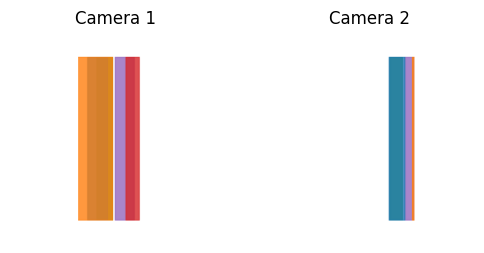

In [3]:
from camera_model import compute_camera_pair
from render import render_camera_image
import matplotlib.pyplot as plt


# rendera bilder
img1 = render_camera_image(cam1, proj1, cylinders, colors)
img2 = render_camera_image(cam2, proj2, cylinders, colors)

# visa
fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(img1)
axs[0].set_title("Camera 1")
axs[0].axis("off")

axs[1].imshow(img2)
axs[1].set_title("Camera 2")
axs[1].axis("off")

plt.show()

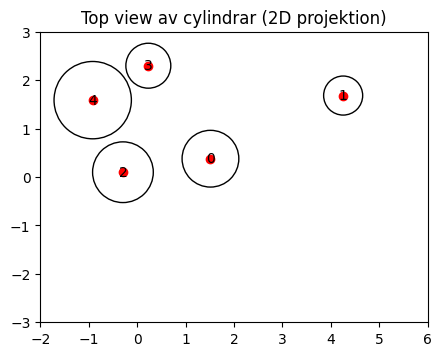

In [4]:
import matplotlib.pyplot as plt

# -----------------------
# Plot (top view = cirklar)
# -----------------------
fig, ax = plt.subplots(figsize=(5,5))

for i, (x, y, r, h) in enumerate(cylinders):
    circ = plt.Circle((x, y), r, fill=False)
    ax.add_patch(circ)
    ax.plot(x, y, 'ro')
    ax.text(x, y, str(i), ha='center', va='center')

ax.set_aspect('equal')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Top view av cylindrar (2D projektion)")

plt.show()

In [5]:
from camera_model import compute_camera_pair

cam1, cam2, proj1, proj2 = compute_camera_pair(cylinders, seed=42)

for (i, u, v, r, d) in proj1:
    circ = plt.Circle((u, v), r, fill=False)
    ax.add_patch(circ)

TypeError: compute_camera_pair() missing 1 required positional argument: 'bounds'

In [ ]:
from camera_model import compute_camera_pair
from plotting import plot_camera_pair
import matplotlib.pyplot as plt


cmap = plt.get_cmap("tab10")
colors = {i: cmap(i) for i in range(len(circles))}

num_pairs = 3

fig, axs = plt.subplots(num_pairs, 3, figsize=(15, 4 * num_pairs))

if num_pairs == 1:
    axs = [axs]

for i in range(num_pairs):
    cam1, cam2, proj1_all, vis1, proj2_all, vis2 = compute_camera_pair(
        circles, seed=42 + i
    )

    plot_camera_pair(
        axs[i],
        circles,
        cam1,
        cam2,
        proj1_all,
        vis1,
        proj2_all,
        vis2,
        bounds,
        colors
    )

plt.tight_layout()
plt.show()

In [ ]:
from vision import build_vision_pair

mat_cam1, mat_cam2 = build_vision_pair(
    proj1_all, vis1,
    proj2_all, vis2,
    circles
)


In [ ]:
import matplotlib.pyplot as plt

def plot_vision_matrix(mat, title):
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    
    labels = ["Occupancy", "Radius", "Depth"]
    cmaps = ['gray', 'viridis', 'inferno']
    
    for i in range(3):
        data = mat[:, i].reshape(-1, 1)  # gör till 2D för imshow
        
        im = axs[i].imshow(
            data,
            aspect='auto',
            origin='lower',
            extent=[0, 1, -90, 90],  # grader
            cmap=cmaps[i]
        )
        
        axs[i].set_title(labels[i])
        axs[i].set_ylabel("Vinkel (grader)")
        axs[i].set_xticks([])
        
        plt.colorbar(im, ax=axs[i])
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# -----------------------
# Plot för båda kameror
# -----------------------
plot_vision_matrix(mat_cam1, "Camera 1 Vision Matrix")
plot_vision_matrix(mat_cam2, "Camera 2 Vision Matrix")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Hjälpfunktioner
# -----------------------
def ray_from_camera(cam, angle):
    """Returnerar en ray: punkt + riktning"""
    dir_world = np.array([
        np.cos(cam.theta - angle),
        np.sin(cam.theta - angle)
    ])
    return cam.c, dir_world


def intersect_rays(p1, d1, p2, d2):
    """Minsta-kvadrat lösning för två rays"""
    A = np.stack([d1, -d2], axis=1)
    b = p2 - p1
    
    if np.linalg.matrix_rank(A) < 2:
        return None
    
    t = np.linalg.lstsq(A, b, rcond=None)[0]
    
    point1 = p1 + t[0] * d1
    point2 = p2 + t[1] * d2
    
    return 0.5 * (point1 + point2)


# -----------------------
# Rekonstruktion
# -----------------------
reconstructed = []

# vi matchar bara baserat på index (enkelt case)
for idx1, umin1, umax1 in vis1:
    for idx2, umin2, umax2 in vis2:
        
        if idx1 != idx2:
            continue
        
        # mittvinkel
        mid1 = 0.5 * (umin1 + umax1)
        mid2 = 0.5 * (umin2 + umax2)
        
        # rays
        p1, d1 = ray_from_camera(cam1, mid1)
        p2, d2 = ray_from_camera(cam2, mid2)
        
        pt = intersect_rays(p1, d1, p2, d2)
        
        if pt is None:
            continue
        
        # ta radie från ena kameran (approx)
        R = circles[idx1][2]
        
        reconstructed.append((pt[0], pt[1], R, idx1))


# -----------------------
# Plot jämförelse
# -----------------------
fig, ax = plt.subplots(figsize=(6,6))

# original
for i, (x, y, r) in enumerate(circles):
    circ = plt.Circle((x, y), r, fill=False, linestyle='--', color='gray')
    ax.add_patch(circ)
    ax.text(x, y, str(i), color='gray')

# rekonstruerade
for x, y, r, idx in reconstructed:
    circ = plt.Circle((x, y), r, fill=False, color='red')
    ax.add_patch(circ)
    ax.text(x, y, f"R{idx}", color='red')

# kameror
def draw_camera(ax, cam, color):
    c = cam.c
    d = cam.dir
    ax.plot(c[0], c[1], 'o', color=color)
    ax.arrow(c[0], c[1], d[0], d[1], head_width=0.1, color=color)

draw_camera(ax, cam1, 'blue')
draw_camera(ax, cam2, 'green')

ax.set_aspect('equal')
ax.set_title("Rekonstruktion (röd) vs original (grå)")
ax.set_xlim(-2, 6)
ax.set_ylim(-3, 3)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Projektion mellan kameror
# -----------------------
def project_angle_between_cameras(cam1, cam2, theta1, depth):
    # ray i världen från cam1
    dir1 = np.array([
        np.cos(cam1.theta - theta1),
        np.sin(cam1.theta - theta1)
    ])
    
    p_world = cam1.c + depth * dir1
    
    # projektera till cam2
    v = p_world - cam2.c
    theta2 = np.arctan2(v[1], v[0])
    
    rel2 = cam2.theta - theta2
    
    # wrap
    rel2 = (rel2 + np.pi) % (2*np.pi) - np.pi
    
    return rel2


# -----------------------
# Generera kurvor
# -----------------------
theta1_vals = np.linspace(-np.pi/2, np.pi/2, 200)

# olika djup → olika kurvor
depths = [1.0, 2.0, 3.0, 5.0]

plt.figure(figsize=(6,6))

for d in depths:
    theta2_vals = []
    
    for t1 in theta1_vals:
        t2 = project_angle_between_cameras(cam1, cam2, t1, d)
        theta2_vals.append(t2)
    
    plt.plot(theta1_vals, theta2_vals, label=f"d={d}")

# -----------------------
# Rita observationer
# -----------------------
# Kamera 1 intervall (x)
for idx, umin, umax in vis1:
    plt.plot([umin, umax], [0, 0], linewidth=4, alpha=0.3)

# Kamera 2 intervall (y)
for idx, umin, umax in vis2:
    plt.plot([0, 0], [umin, umax], linewidth=4, alpha=0.3)

# -----------------------
# Layout
# -----------------------
plt.xlabel("θ₁ (Camera 1)")
plt.ylabel("θ₂ (Camera 2)")
plt.title("Epipolära kurvor (θ₁ → θ₂)")

plt.xlim(-np.pi/2, np.pi/2)
plt.ylim(-np.pi/2, np.pi/2)

plt.legend()
plt.grid()
plt.show()